In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from matplotlib.lines import Line2D
from nettcr.models import NetTCR
from scipy import stats
from sklearn.metrics import roc_auc_score

from tcr_antigen_prediction.models import TCRStructMap

In [2]:
model_names = ('TCRStructMap', 'NetTCR')
data_splits = ('random', 'peptide', 'pMHC')

base_dir = Path('data/processed/')

predictions = []
for data_split in data_splits:
    sequences = pd.read_csv(f'data/interim/sequences_{data_split}_split.csv', index_col='index')

    for model_name in model_names:
        prediction_set = pd.read_csv(str(base_dir / f'{model_name}_predictions_on_sequences_{data_split}_split.csv'))

        prediction_set['model_name'] = model_name
        prediction_set['data_split'] = data_split

        prediction_set = prediction_set.merge(sequences, how='left', left_on='index', right_index=True)

        predictions.append(prediction_set)

predictions = pd.concat(predictions).reset_index(drop=True)
predictions = predictions[predictions['fold'] == predictions['sub_model_number']].reset_index(drop=True)

## Model Size

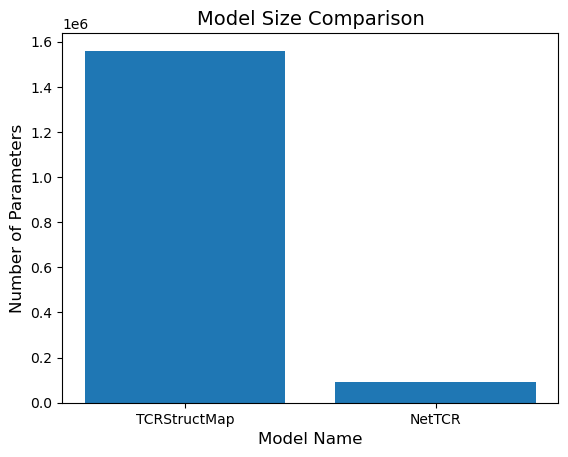

TCRStructMap size: 1559983
NetTCR size: 92529


In [3]:
def count_parameters(model: torch.nn.Module) -> int:
    """Count the number of parmeters in a pytorch model."""
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


model_sizes = [
    (model_name, count_parameters(model))
    for model_name, model in (('TCRStructMap', TCRStructMap()), ('NetTCR', NetTCR()))
]
plt.bar(x=[model_name for model_name, _ in model_sizes], height=[model_size for _, model_size in model_sizes])

plt.title('Model Size Comparison', fontsize=14)
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('Number of Parameters', fontsize=12)

plt.show()

print('\n'.join([f'{model_name} size: {model_size}' for model_name, model_size in model_sizes]))

## Bootstrap ROC-AUC

In [4]:
NUM_SAMPLES = 25
SAMPLE_SIZE = 500

indices = predictions['index'].unique()
rng = np.random.default_rng(123)

samples_metric_scores = []
for sample_num in range(1, NUM_SAMPLES + 1):
    sample_indices = rng.choice(indices, SAMPLE_SIZE)

    sample = predictions[predictions['index'].isin(sample_indices)]

    for (model_name, data_split), group in sample.groupby(['model_name', 'data_split']):
        score = roc_auc_score(group['label'], group['prediction'])
        samples_metric_scores.append(
            {
                'sample_num': sample_num,
                'data_split': data_split,
                'model_name': model_name,
                'roc_auc_score': score,
            }
        )

samples_metric_scores = pd.DataFrame(samples_metric_scores)

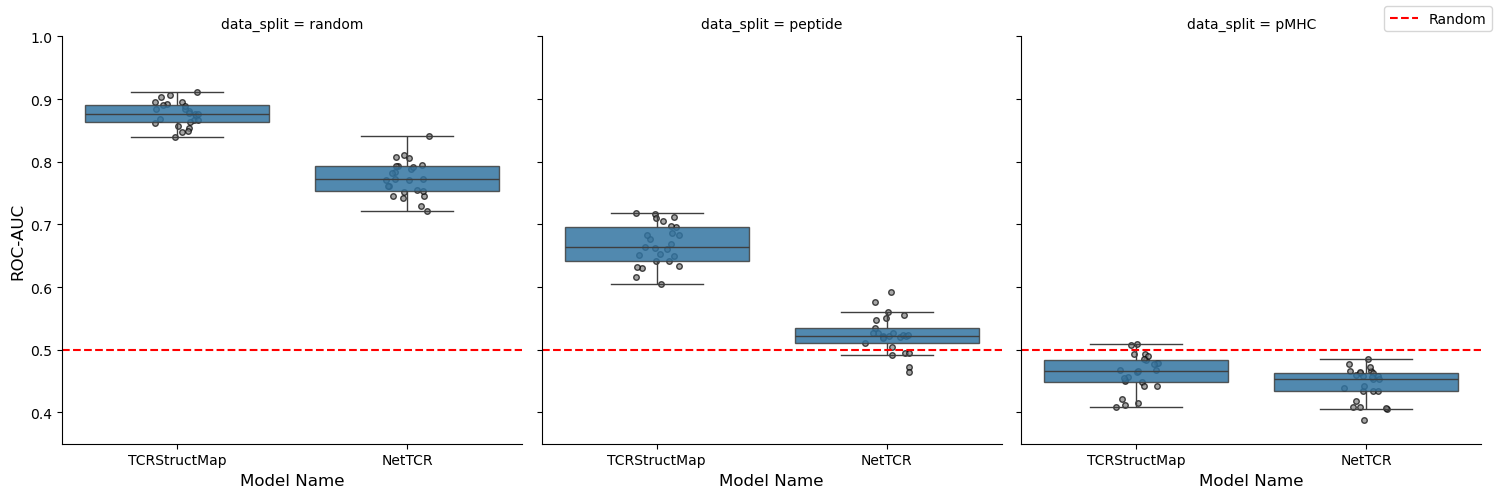

In [5]:
grid = sns.FacetGrid(samples_metric_scores, col='data_split', col_order=data_splits, sharex=False, height=5)

grid.map_dataframe(
    sns.boxplot,
    x='model_name',
    y='roc_auc_score',
    order=model_names,
    showfliers=False,
    boxprops={'alpha': 0.85},
    zorder=1,
)
grid.map_dataframe(
    sns.stripplot,
    x='model_name',
    y='roc_auc_score',
    order=model_names,
    color='grey',
    marker='o',
    size=4,
    edgecolor='black',
    linewidth=1,
    alpha=0.70,
    zorder=0,
)

grid.refline(y=0.5, color='red')
refline_handle = Line2D([0], [0], color='red', linestyle='--', label='Random')
grid.figure.legend(handles=[refline_handle], loc='upper right')

grid.set(ylim=(0.35, 1.0))
grid.set_axis_labels('Model Name', 'ROC-AUC', fontsize=12)

plt.savefig('report/figures/comparison_TCRStructMap_NetTCR.svg')
plt.show()

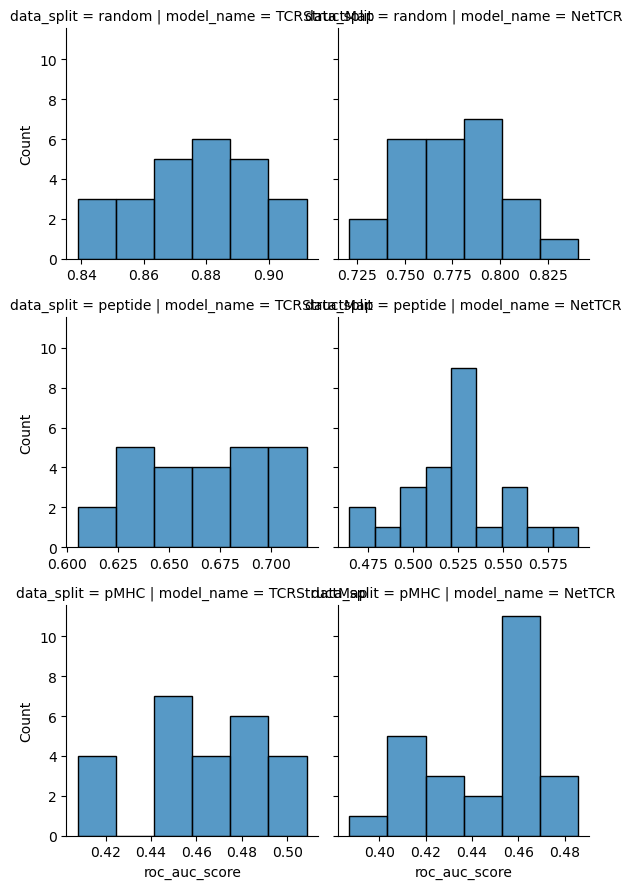

In [6]:
grid = sns.FacetGrid(
    samples_metric_scores,
    row='data_split',
    col='model_name',
    row_order=data_splits,
    col_order=model_names,
    sharex=False,
)
grid.map_dataframe(sns.histplot, x='roc_auc_score')

plt.show()

In [7]:
for data_split, data_group in samples_metric_scores.set_index('sample_num').sort_index().groupby('data_split'):
    print(data_split)
    print(
        stats.ttest_rel(
            data_group.query("model_name == 'TCRStructMap'")['roc_auc_score'],
            data_group.query("model_name == 'NetTCR'")['roc_auc_score'],
            alternative='greater',
        )
    )

    print()

pMHC
TtestResult(statistic=np.float64(4.148521862974196), pvalue=np.float64(0.00018089579144915609), df=np.int64(24))

peptide
TtestResult(statistic=np.float64(22.813321976373004), pvalue=np.float64(4.429610003763589e-18), df=np.int64(24))

random
TtestResult(statistic=np.float64(18.29891634313508), pvalue=np.float64(6.66343198786044e-16), df=np.int64(24))

